In [1]:
# ─── CELL 1: Install / upgrade dependencies ────────────────

!pip install -q ranx

!git clone https://github.com/TalentCLEF/talentclef26_evaluation_script.git /kaggle/working/talentclef26_evaluation_script

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 7.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.7/149.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.5 MB/s eta 0:00:00
Cloning into '/kaggle/working/talentclef26_evaluation_script'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 64 (delta 7), reused 60 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 29.46 KiB | 1.55 MiB/s, done.
Resolving deltas: 100%

In [2]:
# ─── CELL 2: Imports ───────────────────────────────────────

import os, gc, math, random, warnings, subprocess
import glob
import numpy as np
import pandas as pd
import ranx

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import Dataset

from pathlib import Path
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [3]:
# ─── CELL 3: Reproducibility & device setup ────────────────

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Primary device: {DEVICE}")

GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Primary device: cuda


In [4]:
# ─── CELL 4: Configuration ─────────────────────────────────

MODEL_NAME = "jjzha/jobbert-base-cased"
OUTPUT_DIR = "/kaggle/working/jobbert_output"
LOGGING_DIR = "/kaggle/working/jobbert_logs"

# Paths
TRAIN_CSV = (
    "/kaggle/input/datasets/danielantoniudumitru/"
    "clef-talentclef-subtaska/A/Training/"
    "normalization/job_applicant_dataset.csv"
)
DEV_BASE = "/kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en"
CORPUS_DIR = os.path.join(DEV_BASE, "corpus")
QUERY_DIR = os.path.join(DEV_BASE, "queries")
QRELS_FILE = os.path.join(DEV_BASE, "qrels.tsv")

# Hyper-parameters
MAX_LEN = 512
TRAIN_BATCH = 8
EVAL_BATCH = 16
GRAD_ACCUM = 4
NUM_EPOCHS = 5
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

In [5]:
# ─── CELL 5: Load & inspect training data ──────────────────

print("Loading training CSV …")
df_train = pd.read_csv(TRAIN_CSV)
print(f"Shape : {df_train.shape}")
print(df_train.head(3))
print("\nColumn dtypes:\n", df_train.dtypes)
print("\nValue counts (label):\n", df_train.iloc[:, -1].value_counts())

Loading training CSV …
Shape : (10000, 9)
  Job Applicant Name  Age  Gender             Race   Ethnicity  \
0       Daisuke Mori   29    Male  Mongoloid/Asian  Vietnamese   
1     Taichi Shimizu   31    Male  Mongoloid/Asian    Filipino   
2       Sarah Martin   46  Female  White/Caucasian       Dutch   

                                              Resume          Job Roles  \
0  Daisuke Mori\n243 Hill Street\nAmsterdam, Nort...      Fitness Coach   
1  Taichi Shimizu\n108 Market Street\nCape Town, ...          Physician   
2  Sarah Martin\n10 Lincoln Avenue\nMumbai, Mahar...  Financial Analyst   

                                     Job Description  Best Match  
0  Fitness Coach\n\nA Fitness Coach is responsibl...           0  
1  Physician\n\nDiagnose and treat illnesses, pre...           0  
2  Financial Analyst\n\nAs a Financial Analyst, y...           0  

Column dtypes:
 Job Applicant Name    object
Age                    int64
Gender                object
Race                

In [6]:
# ─── CELL 6: Define columns (hardcoded for this dataset) ───

text_a_col = "Job Description"
text_b_col = "Resume"
label_col = "Best Match"

print(f"Text A: {text_a_col}")
print(f"Text B: {text_b_col}")
print(f"Label: {label_col}")

df_train[label_col] = df_train[label_col].astype(int)
assert set(df_train[label_col].unique()).issubset({0, 1}), \
    "Label column must contain only 0 and 1!"

Text A: Job Description
Text B: Resume
Label: Best Match


In [7]:
# ─── CELL 7: Train / validation split ──────────────────────

df_train_split, df_val_split = train_test_split(
    df_train, test_size=0.1, stratify=df_train[label_col], random_state=SEED
)
print(f"Train size : {len(df_train_split)}")
print(f"Val size : {len(df_val_split)}")

Train size : 9000
Val size : 1000


In [8]:
# ─── CELL 8: Tokenizer ─────────────────────────────────────

print(f"\nLoading tokenizer: {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Loading tokenizer: jjzha/jobbert-base-cased …


config.json:   0%|          | 0.00/603 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [9]:
# ─── CELL 9: Helper — read dev corpus / queries ───────────

def read_text_file(folder, file_id):
    path = os.path.join(folder, str(file_id))
    if not os.path.exists(path):
        return ""
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        return f.read().strip()

In [10]:
# ─── CELL 10: Load qrels ───────────────────────────────────

print("\nLoading qrels …")
qrels = pd.read_csv(
    QRELS_FILE, sep="\t", header=None,
    names=["q_id", "iter", "c_id", "relevance"]
)
print(f"qrels shape: {qrels.shape}")
print(qrels.head())


Loading qrels …
qrels shape: (472, 4)
    q_id  iter   c_id  relevance
0  36044     0  13884          1
1  39060     0   9516          1
2  39060     0  12097          1
3  32447     0  13882          1
4  39060     0   6533          1


In [11]:
# ─── CELL 11: Load all corpus & query files, build all pairs ───

print("\nLoading all query files …")
query_dict = {}
for fpath in sorted(glob.glob(os.path.join(QUERY_DIR, "*"))):
    fid = os.path.basename(fpath)
    query_dict[fid] = read_text_file(QUERY_DIR, fid)
print(f"  Queries found: {len(query_dict)}")

print("Loading all corpus files …")
corpus_dict = {}
for fpath in sorted(glob.glob(os.path.join(CORPUS_DIR, "*"))):
    fid = os.path.basename(fpath)
    corpus_dict[fid] = read_text_file(CORPUS_DIR, fid)
print(f"  Corpus elements found: {len(corpus_dict)}")

positive_set = set(zip(
    qrels["q_id"].astype(str),
    qrels["c_id"].astype(str)
))

print("\nBuilding all (query × corpus) pairs …")
dev_records = []
for q_id, q_text in tqdm(query_dict.items(), desc="Queries"):
    for c_id, c_text in corpus_dict.items():
        dev_records.append({
            "q_id": q_id,
            "c_id": c_id,
            "query_text": q_text,
            "corpus_text": c_text,
            "relevance": 1 if (q_id, c_id) in positive_set else 0,
        })

df_dev = pd.DataFrame(dev_records)

print(f"Total pairs: {len(df_dev)}")
print(f"Positives: {(df_dev['relevance']==1).sum()}")
print(f"Negatives: {(df_dev['relevance']==0).sum()}")


Loading all query files …
  Queries found: 10
Loading all corpus files …
  Corpus elements found: 472

Building all (query × corpus) pairs …


Queries:   0%|          | 0/10 [00:00<?, ?it/s]

Total pairs: 4720
Positives: 472
Negatives: 4248


In [12]:
# ─── CELL 12: Dataset class ─────────────────────────────────

class PairDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len,
                 col_a, col_b, label_col):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.col_a = col_a
        self.col_b = col_b
        self.label_col = label_col

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row  = self.data.iloc[idx]

        def clean_text(t):
            return " ".join(str(t).split()[:256]) if pd.notna(t) else ""

        text_a = clean_text(row[self.col_a]) if pd.notna(row[self.col_a]) else ""
        text_b = clean_text(row[self.col_b]) if pd.notna(row[self.col_b]) else ""
        
        encoding = self.tokenizer(
            text_a,
            text_b,
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_token_type_ids=True
        )
        encoding["labels"] = int(row[self.label_col])
        return encoding


train_dataset = PairDataset(df_train_split, tokenizer, MAX_LEN,
                             text_a_col, text_b_col, label_col)
val_dataset   = PairDataset(df_val_split,  tokenizer, MAX_LEN,
                             text_a_col, text_b_col, label_col)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Sample encoding keys: {list(train_dataset[0].keys())}")

Sample encoding keys: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']


In [13]:
# ─── CELL 13: Model ────────────────────────────────────────

print(f"\nLoading model: {MODEL_NAME} …")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

class RankingTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[:, 1]

        pos_mask = labels == 1
        neg_mask = labels == 0

        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            loss_fn = torch.nn.CrossEntropyLoss()
            return (loss_fn(logits, labels), outputs) if return_outputs else loss_fn(logits, labels)

        pos_scores = probs[pos_mask]
        neg_scores = probs[neg_mask]

        pos_exp = pos_scores.unsqueeze(1).expand(-1, neg_scores.size(0))
        neg_exp = neg_scores.unsqueeze(0).expand(pos_scores.size(0), -1)

        margin = 0.3
        loss = torch.clamp(margin - pos_exp + neg_exp, min=0).mean()
        return (loss, outputs) if return_outputs else loss


Loading model: jjzha/jobbert-base-cased …


model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: jjzha/jobbert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider train

Model parameters: 108,311,810


In [14]:
# ─── CELL 14: Metrics ──────────────────────────────────────

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "ap": average_precision_score(labels, probs)
    }

In [15]:
# ─── CELL 15: TrainingArguments ────────────────────────────

steps_per_epoch = math.ceil(len(train_dataset) / (TRAIN_BATCH * max(NUM_GPUS, 1) * GRAD_ACCUM))
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

os.environ["TENSORBOARD_LOGGING_DIR"] = LOGGING_DIR

training_args = TrainingArguments(
    output_dir = OUTPUT_DIR,
    logging_dir = LOGGING_DIR,

    # Epochs & batch
    num_train_epochs = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size = EVAL_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,

    # Optimiser
    learning_rate = LR,
    weight_decay = WEIGHT_DECAY,
    warmup_steps = warmup_steps,
    lr_scheduler_type = "cosine",

    # Evaluation & saving
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "ap",
    greater_is_better = True,

    # Logging
    report_to = "none",

    # Multi-GPU / precision
    fp16 = True,
    dataloader_num_workers = 4,
    seed = SEED,

    # Progress bar
    disable_tqdm = False
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [16]:
# ─── CELL 16: Trainer ──────────────────────────────────────

trainer = RankingTrainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = val_dataset,
    processing_class = tokenizer,
    data_collator = data_collator,
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
)

In [17]:
# ─── CELL 17: Training ─────────────────────────────────────

print("\n" + "="*60)
print("  Starting JobBERT fine-tuning …")
print("="*60)

train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nTraining summary:")
print(train_result.metrics)


  Starting JobBERT fine-tuning …


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Ap
1,No log,0.290280,0.511000,0.663918,0.497938,0.995876,0.502613
2,No log,0.249399,0.585000,0.608121,0.560976,0.663918,0.594358
3,No log,0.117012,0.787000,0.769730,0.809091,0.734021,0.832542
4,0.863228,0.082432,0.857000,0.848997,0.870130,0.828866,0.858009
5,0.863228,0.080754,0.860000,0.850427,0.882483,0.820619,0.864903


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training summary:
{'train_runtime': 2591.2741, 'train_samples_per_second': 17.366, 'train_steps_per_second': 0.272, 'total_flos': 1.18399974912e+16, 'train_loss': 0.6928912981182126, 'epoch': 5.0}


In [18]:
# ─── CELL 18: Dev Dataset class ────────────────────────────

class DevPairDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        def clean_text(t):
            return " ".join(str(t).split()[:256]) if pd.notna(t) else ""

        row = self.data.iloc[idx]
        enc = self.tokenizer(
            clean_text(row["query_text"]),
            clean_text(row["corpus_text"]),
            max_length=self.max_len,
            truncation=True,
            padding=False,
            return_token_type_ids=True,
        )
        enc["labels"] = int(row["relevance"])
        return enc

dev_dataset = DevPairDataset(df_dev, tokenizer, MAX_LEN)

In [19]:
# ─── CELL 19: Inference on dev set ─────────────────────────

print("\nRunning predictions on dev set …")

raw_preds = trainer.predict(dev_dataset)
logits = raw_preds.predictions
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
preds_bin = (probs >= 0.5).astype(int)
labels = raw_preds.label_ids

df_dev["pred_prob"]  = probs
df_dev["pred_label"] = preds_bin


Running predictions on dev set …


In [20]:
# ─── CELL 19b: Generate TREC run file ──────────────────────

RUN_TAG  = "jobbert_run"
RUN_PATH = "/kaggle/working/run_en-en_jobbert.trec"

print("Generating TREC run file …")

run_rows = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank_idx, row in grp_sorted.iterrows():
        run_rows.append({
            "q_id": str(row["q_id"]),
            "Q0": "Q0",
            "doc_id": str(row["c_id"]),
            "rank": int(grp_sorted.index.get_loc(rank_idx)) + 1,
            "score": float(row["pred_prob"]),
            "tag": RUN_TAG
        })

df_run = pd.DataFrame(run_rows)

df_run = []
for q_id, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    for rank, (_, row) in enumerate(grp_sorted.iterrows(), start=1):
        df_run.append({
            "q_id"  : str(row["q_id"]),
            "Q0"    : "Q0",
            "doc_id": str(row["c_id"]),
            "rank"  : rank,
            "score" : float(row["pred_prob"]),
            "tag"   : RUN_TAG,
        })
df_run = pd.DataFrame(df_run)

with open(RUN_PATH, "w") as f:
    for _, row in df_run.iterrows():
        f.write(f"{row['q_id']} {row['Q0']} {row['doc_id']} "
                f"{row['rank']} {row['score']:.10f} {row['tag']}\n")

print(f"Run file saved: {RUN_PATH}")
print(f"  Total lines  : {len(df_run)}")
print(f"  Unique queries: {df_run['q_id'].nunique()}")
print(df_run.head(5).to_string(index=False))

Generating TREC run file …
Run file saved: /kaggle/working/run_en-en_jobbert.trec
  Total lines  : 4720
  Unique queries: 10
 q_id Q0 doc_id  rank    score         tag
29243 Q0  20280     1 0.925995 jobbert_run
29243 Q0  19485     2 0.918103 jobbert_run
29243 Q0  10618     3 0.915754 jobbert_run
29243 Q0   9756     4 0.913569 jobbert_run
29243 Q0  17038     5 0.913424 jobbert_run


In [21]:
# ─── CELL 19c: Official TalentCLEF 2026 evaluation ─────────

qrels_file = QRELS_FILE
run_file   = RUN_PATH

print("Running official TalentCLEF 2026 evaluation …")
print(f"  qrels : {qrels_file}")
print(f"  run   : {run_file}")

command = [
    "python",
    "/kaggle/working/talentclef26_evaluation_script/talentclef_evaluate.py",
    "--task",      "A",
    "--lang-mode", "en",
    "--qrels",     qrels_file,
    "--run",       run_file,
]

result = subprocess.run(command, capture_output=True, text=True)

print("\n" + "="*60)
print("  Official Evaluation Results")
print("="*60)
print(result.stdout)

if result.stderr:
    print("STDERR:")
    print(result.stderr)

Running official TalentCLEF 2026 evaluation …
  qrels : /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  run   : /kaggle/working/run_en-en_jobbert.trec

  Official Evaluation Results
TalentCLEF 2026 - Task A Evaluation
Received parameters:
  Task: A
  Qrels: /kaggle/input/datasets/danielantoniudumitru/clef-talentclef-subtaska/A/Development/en/qrels.tsv
  Run: /kaggle/working/run_en-en_jobbert.trec
  Language Mode: en

Loading qrels...
Loading run...

Running Task A evaluation...

EVALUATION RESULTS
map: 0.1097
mrr: 0.1172
ndcg: 0.5078
precision@5: 0.0600
precision@10: 0.0600
precision@100: 0.0910

STDERR:
/usr/local/lib/python3.12/dist-packages/ranx/metrics/average_precision.py:49: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scores[i] = _average_precision(qrels[i], run[i], k, rel_lvl)



In [22]:
# ─── CELL 20: Ranking Metrics ──────────────────────────────

def mean_average_precision(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    aps = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        if rel.sum() == 0:
            continue
        hits, ap = 0, 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                hits += 1
                ap += hits / rank
        aps.append(ap / rel.sum())
    return np.mean(aps) if aps else 0.0


def mean_reciprocal_rank(df, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    rrs = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).reset_index(drop=True)
        rel = grp_sorted[rel_col].values
        rr = 0.0
        for rank, r in enumerate(rel, start=1):
            if r == 1:
                rr = 1.0 / rank
                break
        rrs.append(rr)
    return np.mean(rrs) if rrs else 0.0


def precision_at_k(df, k, q_col="q_id", prob_col="pred_prob", rel_col="relevance"):
    pk_list = []
    for qid, grp in df.groupby(q_col):
        grp_sorted = grp.sort_values(prob_col, ascending=False).head(k)
        pk_list.append(grp_sorted[rel_col].mean())
    return np.mean(pk_list) if pk_list else 0.0

In [23]:
# ─── CELL 21: Print all metrics ────────────────────────────

acc = accuracy_score(labels, preds_bin)
f1 = f1_score(labels, preds_bin, zero_division=0)
prec = precision_score(labels, preds_bin, zero_division=0)
rec = recall_score(labels, preds_bin, zero_division=0)
ap_overall = average_precision_score(labels, probs)

MAP = mean_average_precision(df_dev)
MRR = mean_reciprocal_rank(df_dev)
P_at1 = precision_at_k(df_dev, k=1)
P_at5 = precision_at_k(df_dev, k=5)
P_at10 = precision_at_k(df_dev, k=10)

print("\n" + "="*60)
print("  JobBERT — Dev Set Evaluation Results")
print("="*60)
print(f"  Accuracy: {acc:.4f}")
print(f"  F1: {f1:.4f}")
print(f"  Precision (binary): {prec:.4f}")
print(f"  Recall: {rec:.4f}")
print(f"  Average Precision: {ap_overall:.4f}")
print("─"*60)
print(f"  MAP(Mean Avg Precision): {MAP:.4f}")
print(f"  MRR(Mean Recip Rank): {MRR:.4f}")
print(f"  P@1: {P_at1:.4f}")
print(f"  P@5: {P_at5:.4f}")
print(f"  P@10: {P_at10:.4f}")
print("="*60)


  JobBERT — Dev Set Evaluation Results
  Accuracy: 0.5883
  F1: 0.1887
  Precision (binary): 0.1175
  Recall: 0.4788
  Average Precision: 0.1119
────────────────────────────────────────────────────────────
  MAP(Mean Avg Precision): 0.1097
  MRR(Mean Recip Rank): 0.1172
  P@1: 0.0000
  P@5: 0.0600
  P@10: 0.0600


In [24]:
# ─── CELL 22: Save predictions ─────────────────────────────

df_dev.to_csv("/kaggle/working/jobbert_dev_predictions.csv", index=False)
print("\nPredictions saved to /kaggle/working/jobbert_dev_predictions.csv")


Predictions saved to /kaggle/working/jobbert_dev_predictions.csv


In [25]:
# ─── CELL 23: Extract training history ─────────────────────

log_history = trainer.state.log_history

train_logs = [e for e in log_history if "loss" in e and "eval_loss" not in e]
eval_logs = [e for e in log_history if "eval_loss" in e]

eval_epochs = [e["epoch"] for e in eval_logs]
eval_loss = [e["eval_loss"] for e in eval_logs]
eval_acc = [e["eval_accuracy"] for e in eval_logs]
eval_f1 = [e["eval_f1"] for e in eval_logs]
eval_prec = [e["eval_precision"] for e in eval_logs]
eval_rec = [e["eval_recall"] for e in eval_logs]
eval_ap = [e["eval_ap"] for e in eval_logs]

train_epochs_raw = [e["epoch"] for e in train_logs]
train_loss_raw = [e["loss"] for e in train_logs]

import numpy as np
epoch_bins = np.arange(1, len(eval_epochs) + 1)
train_loss_per_epoch = []
for ep in eval_epochs:
    lo = ep - 1.0
    vals = [train_loss_raw[i] for i, e in enumerate(train_epochs_raw) if lo < e <= ep]
    train_loss_per_epoch.append(np.mean(vals) if vals else float("nan"))

print(f"Epochs recorded: {eval_epochs}")
print(f"Eval loss: {[round(v,4) for v in eval_loss]}")
print(f"Eval AP: {[round(v,4) for v in eval_ap]}")

Epochs recorded: [1.0, 2.0, 3.0, 4.0, 5.0]
Eval loss: [0.2903, 0.2494, 0.117, 0.0824, 0.0808]
Eval AP: [0.5026, 0.5944, 0.8325, 0.858, 0.8649]


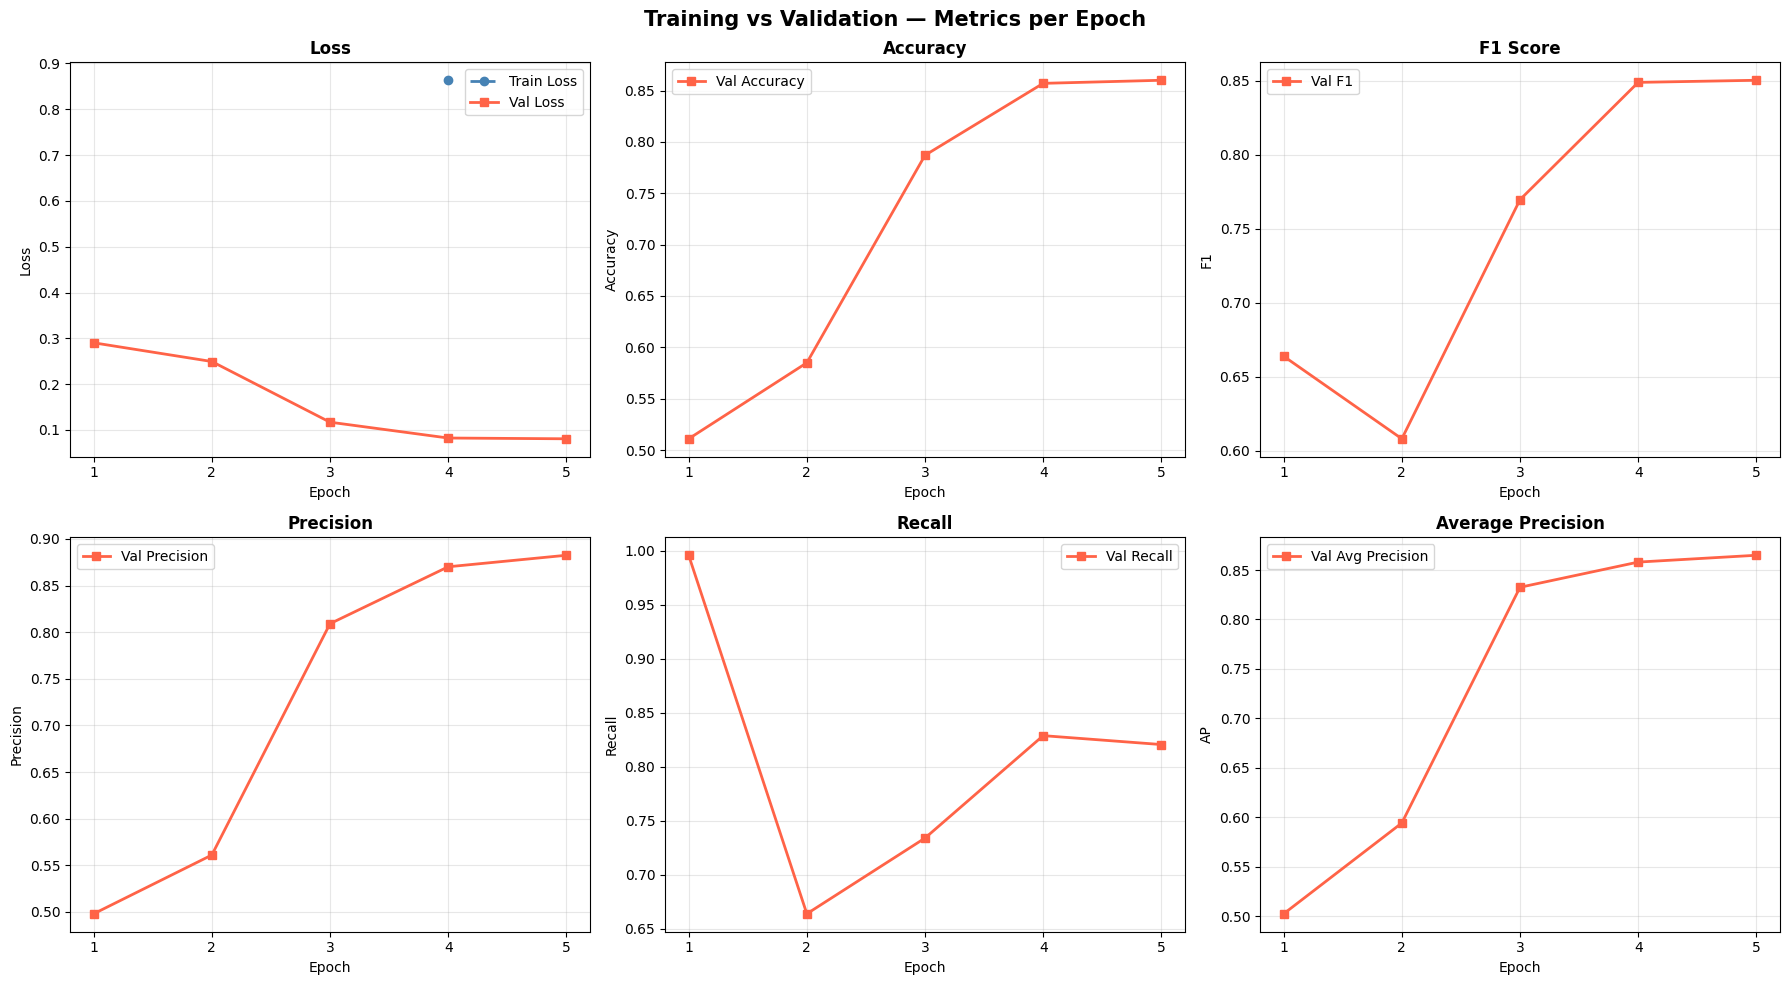

Saved: metrics_per_epoch.png


In [26]:
# ─── CELL 24: Loss & metrics over epochs ───────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training vs Validation — Metrics per Epoch", fontsize=15, fontweight="bold")

def plot_line(ax, y_train, y_eval, label_train, label_eval, title, ylabel):
    ax.plot(eval_epochs, y_train, marker="o", linestyle="--", color="steelblue",
            label=label_train, linewidth=2)
    ax.plot(eval_epochs, y_eval,  marker="s", linestyle="-",  color="tomato",
            label=label_eval, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(eval_epochs)

plot_line(axes[0, 0], train_loss_per_epoch, eval_loss,
          "Train Loss", "Val Loss", "Loss", "Loss")
plot_line(axes[0, 1], [None]*len(eval_epochs), eval_acc,
          "", "Val Accuracy", "Accuracy", "Accuracy")
plot_line(axes[0, 2], [None]*len(eval_epochs), eval_f1,
          "", "Val F1", "F1 Score", "F1")
plot_line(axes[1, 0], [None]*len(eval_epochs), eval_prec,
          "", "Val Precision", "Precision", "Precision")
plot_line(axes[1, 1], [None]*len(eval_epochs), eval_rec,
          "", "Val Recall", "Recall", "Recall")
plot_line(axes[1, 2], [None]*len(eval_epochs), eval_ap,
          "", "Val Avg Precision", "Average Precision", "AP")

for ax in axes.flat:
    handles, lbls = ax.get_legend_handles_labels()
    ax.legend([h for h, l in zip(handles, lbls) if l], 
              [l for l in lbls if l])

plt.tight_layout()
plt.savefig("/kaggle/working/metrics_per_epoch.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: metrics_per_epoch.png")

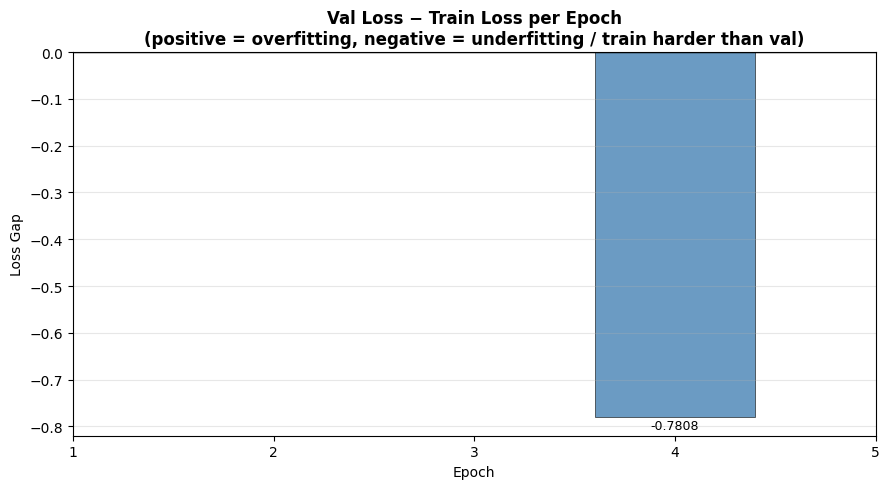

Saved: loss_gap.png


In [27]:
# ─── CELL 25: Loss gap (overfitting indicator) ─────────────

fig, ax = plt.subplots(figsize=(9, 5))

gap = [e - t if t is not None else float("nan")
       for e, t in zip(eval_loss, train_loss_per_epoch)]

ax.bar(eval_epochs, gap, color=["tomato" if g > 0 else "steelblue" for g in gap],
       alpha=0.8, edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Val Loss − Train Loss per Epoch\n"
             "(positive = overfitting, negative = underfitting / train harder than val)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss Gap")
ax.set_xticks(eval_epochs)
ax.grid(True, alpha=0.3, axis="y")

for i, (ep, g) in enumerate(zip(eval_epochs, gap)):
    if not np.isnan(g):
        ax.text(ep, g + (0.001 if g >= 0 else -0.003), f"{g:+.4f}",
                ha="center", va="bottom" if g >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_gap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: loss_gap.png")

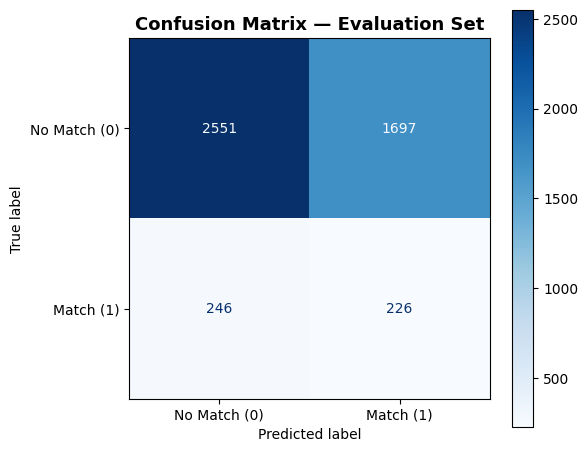

Saved: confusion_matrix.png


In [28]:
# ─── CELL 26: Confusion matrix ─────────────────────────────

cm = confusion_matrix(labels, preds_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Match (0)", "Match (1)"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Evaluation Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: confusion_matrix.png")

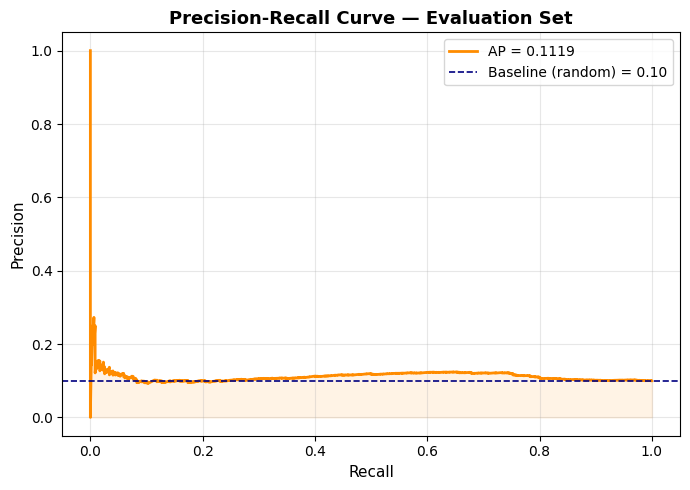

Saved: precision_recall_curve.png


In [29]:
# ─── CELL 27: Precision-Recall curve ───────────────────────

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(labels, probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, color="darkorange", linewidth=2,
        label=f"AP = {ap_overall:.4f}")
ax.fill_between(recall_curve, precision_curve, alpha=0.1, color="darkorange")
ax.axhline(y=labels.mean(), color="navy", linestyle="--", linewidth=1.2,
           label=f"Baseline (random) = {labels.mean():.2f}")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve — Evaluation Set", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: precision_recall_curve.png")

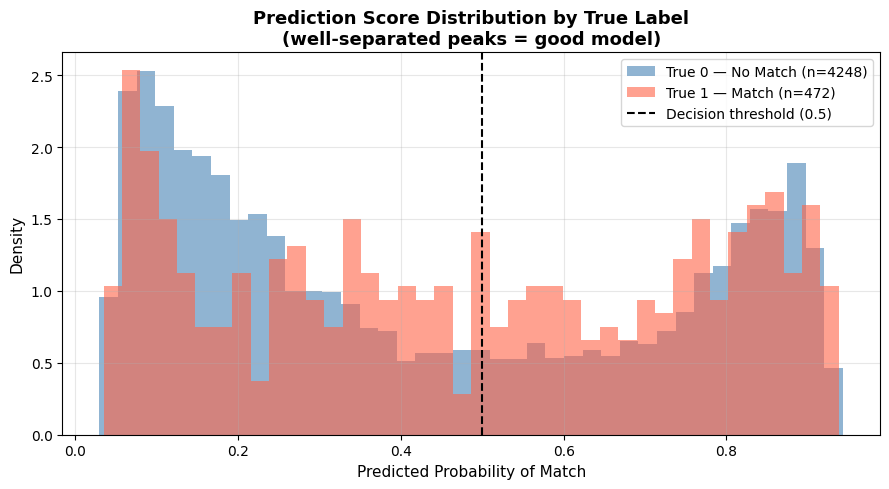

Saved: score_distribution.png


In [30]:
# ─── CELL 28: Score distribution by true class ─────────────

fig, ax = plt.subplots(figsize=(9, 5))

pos_probs = probs[labels == 1]
neg_probs = probs[labels == 0]

ax.hist(neg_probs, bins=40, alpha=0.6, color="steelblue",
        label=f"True 0 — No Match (n={len(neg_probs)})", density=True)
ax.hist(pos_probs, bins=40, alpha=0.6, color="tomato",
        label=f"True 1 — Match (n={len(pos_probs)})", density=True)
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Decision threshold (0.5)")
ax.set_xlabel("Predicted Probability of Match", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Prediction Score Distribution by True Label\n"
             "(well-separated peaks = good model)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: score_distribution.png")

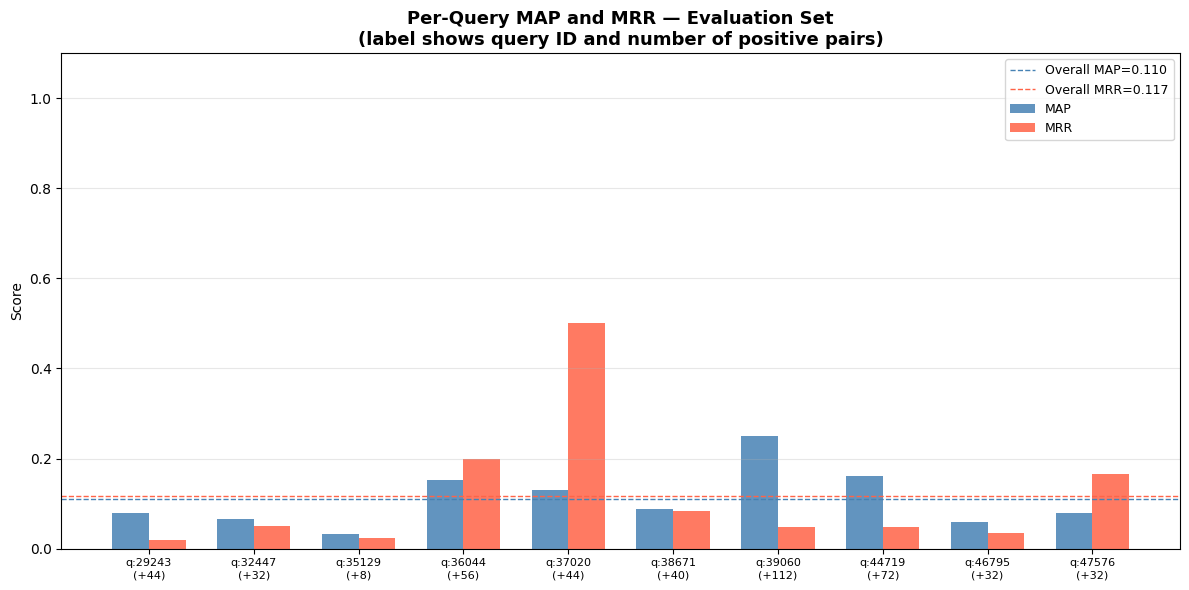

Saved: per_query_map_mrr.png


In [31]:
# ─── CELL 29: Per-query ranking metrics breakdown ──────────

query_ids, query_maps, query_mrrs, query_pos_counts = [], [], [], []

for qid, grp in df_dev.groupby("q_id"):
    grp_sorted = grp.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    rel = grp_sorted["relevance"].values

    # MAP
    hits, ap = 0, 0.0
    for rank, r in enumerate(rel, start=1):
        if r == 1:
            hits += 1
            ap += hits / rank
    q_map = ap / rel.sum() if rel.sum() > 0 else 0.0

    # MRR
    q_mrr = 0.0
    for rank, r in enumerate(rel, start=1):
        if r == 1:
            q_mrr = 1.0 / rank
            break

    query_ids.append(str(qid))
    query_maps.append(q_map)
    query_mrrs.append(q_mrr)
    query_pos_counts.append(int(rel.sum()))

x = np.arange(len(query_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(max(12, len(query_ids) * 1.2), 6))
bars1 = ax.bar(x - width/2, query_maps, width, label="MAP",  color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, query_mrrs, width, label="MRR",  color="tomato",    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"q:{qid}\n(+{n})" for qid, n in zip(query_ids, query_pos_counts)],
                   fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-Query MAP and MRR — Evaluation Set\n"
             "(label shows query ID and number of positive pairs)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=MAP, color="steelblue", linestyle="--", linewidth=1,
           label=f"Overall MAP={MAP:.3f}")
ax.axhline(y=MRR, color="tomato",    linestyle="--", linewidth=1,
           label=f"Overall MRR={MRR:.3f}")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/per_query_map_mrr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: per_query_map_mrr.png")